# Update 2025-09-01
Jun Ishigohoka

In [1]:
import hanoi
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

# How to represent data

Population size $N$

In [2]:
N = 18

Number of traits $n$

In [3]:
n = 2

Number of loci L

In [4]:
L = 5

## Mutation effect
### Phenotypic mean

Effect of allele `1` at $L$  loci on **mean (phenotypic expectation)** of $n$ traits compared to allele `0` is represented in $M_m$, a 2D array ($n \times L$) 

$M_m = 
\begin{pmatrix}
\mu_{1(0,0)} & \mu_{1(0,1)} & ... & \mu_{1,(0,L-1)}\\
\mu_{1(1,0)} & \mu_{1(1,1)} & ... & \mu_{1,(1,L-1)}\\
\vdots & \vdots & \vdots & \vdots\\
\vdots & \vdots & \mu_{1(j,l)} & \vdots\\
\vdots & \vdots & \vdots & \vdots\\
\mu_{1(n-1,0)} & \mu_{1(n-1,1)} & ... & \mu_{1,(n-1,L-1)}\\
\end{pmatrix}
$

In [5]:
M_m = np.array([[1, 0, 0, 0, 0], 
                [0, 1, 0, 0, 0]],
               dtype = np.float64
               )
print(M_m)

[[1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]]


In this scenario, allele `1` of locus 0 increases phenotype of trait 1 by 1.0, and allele `1` of locus 1 increases the phenotype of trait 2 by 1.0

### Phenotypic variance

Effect of allele `1` at $L$  loci on **variance (phenotypic noise)** of $n$ traits compared to allele `0` is represented in $M_v$, a 2D array ($n \times L$) 

$M_v = 
\begin{pmatrix}
\sigma^2_{1(0,0)} & \sigma^2_{1(0,1)} & ... & \sigma^2_{1,(0,L-1)}\\
\sigma^2_{1(1,0)} & \sigma^2_{1(1,1)} & ... & \sigma^2_{1,(1,L-1)}\\
\vdots & \vdots & \vdots & \vdots\\
\vdots & \vdots & \sigma^2_{1(j,l)} & \vdots\\
\vdots & \vdots & \vdots & \vdots\\
\sigma^2_{1(n-1,0)} & \sigma^2_{1(n-1,1)} & ... & \sigma^2_{1,(n-1,L-1)}\\
\end{pmatrix}
$

In [6]:
M_v = np.array([[0, 0, 0.01, 0, 0], 
                [0, 0, 0, 0.01, 0]],
               dtype = np.float64
               )
print(M_v)

[[0.   0.   0.01 0.   0.  ]
 [0.   0.   0.   0.01 0.  ]]


In this scenario, allele `1` of locus 2 increases the variance of trait 1 by 0.01 (so increase SD by 0.1), and allele `1` of locus 3 increases the variance of trait 2 by 0.01.

### Phenotypic covariance

Effect of allele `1` at $L$  loci on **covariance ((in)dependence of development among traits)** of $\binom{n}{2}$ traits compared to allele `0` is represented in $M_v$, a 2D array ($\binom{n}{2} \times L$) 

$M_c = 
\begin{pmatrix}
cov_{1((0,1), 0)} & cov_{1((0,1), 1)} & ... & cov_{1((0,1), L-1)}\\
cov_{1((0,2), 0)} & cov_{1((0,2), 1)} & ... & cov_{1((0,2), L-1)}\\
\vdots & \vdots & \vdots & \vdots\\
\vdots & \vdots & cov_{1((j,k),l)} & \vdots\\
\vdots & \vdots & \vdots & \vdots\\
cov_{1((n-2,n-1), 0)} & cov_{1((n-2,n-1), 1)} & ... & cov_{1((n-2,n-1), L-1)}
\end{pmatrix}
$

In [7]:
M_c = np.array([[0, 0, 0, 0, -0.009]],
               dtype = np.float64
               )
print(M_c)

[[ 0.     0.     0.     0.    -0.009]]


In this scenario, allele `1` of locus 4 reduces the covariance between trait 0 and trait 2 by 0.0009.

Note when $n = 1$, $M_c$ is empty, with 0 rows

Note for now I am assuming that each locus has one effect.
In other words, I assume **no pleiotropy between traits**, and **no expectation-noise dependence**.

In [8]:
np.concatenate((M_m, M_v, M_c), axis = 0)

array([[ 1.   ,  0.   ,  0.   ,  0.   ,  0.   ],
       [ 0.   ,  1.   ,  0.   ,  0.   ,  0.   ],
       [ 0.   ,  0.   ,  0.01 ,  0.   ,  0.   ],
       [ 0.   ,  0.   ,  0.   ,  0.01 ,  0.   ],
       [ 0.   ,  0.   ,  0.   ,  0.   , -0.009]])

### hanoi.MutEffect

In `hanoi`, mutation effects of loci on traits are represented by objects of `MutEffect` type.

In [9]:
hanoi.MutEffect?

Init signature:
hanoi.MutEffect(
    mean: numpy.ndarray,
    var: numpy.ndarray,
    cov: numpy.ndarray,
)
Docstring:     
A class to represent mutational effects on mean, variance, and covariance of traits.

Attributes
----------
mean : Mean effects. 
    Should be a 2D np.array of shape (n, L). 
    mean[i, j] holds the effect of allele 1 at locus j on trait i.
var : Variance effects.
    Should be a 2D np.array of shape (n, L).
    var[i, j] holds the effect of allele 1 at locus j on trait i.
cov : Covariance effects.
    Should be a 2D np.array of shape (choose(n, 2), L).
    cov[i, j] holds the effect of allele 1 at locus j on the i-th trait pair.
n : Number of traits
L : Number of loci


Methods
-------
show() : Prints information of the MutEffect object.
File:           ~/SeaDrive/My Libraries/mylib/work/projects/python/packages/hanoi/hanoi/hanoi.py
Type:           type
Subclasses:     

In [10]:
M = hanoi.MutEffect(mean = M_m, var = M_v, cov = M_c)
M.show()

Number of traits n:
2
Number of trait pairs:
1
Number of loci L:
5
Mutation effect of mean:
[[1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]]
Mutation effect of variance:
[[0.   0.   0.01 0.   0.  ]
 [0.   0.   0.   0.01 0.  ]]
Mutation effect of covariance:
[[ 0.     0.     0.     0.    -0.009]]


## Genotype

The genotypes of $N$ diploid individuals at $L$ loci are represented as a matrix of $(L, N)$ (like VCF).

$G = 
\begin{pmatrix}
g_{0,0} & g_{0, 1} & ... & g_{0, L-1}\\
g_{1,0} & g_{1, 1} & ... & g_{1, L-1}\\
\vdots & \vdots & \vdots & \vdots\\
\vdots & \vdots & g_{i,l} & \vdots\\
\vdots & \vdots & \vdots & \vdots\\
g_{N-1,0} & g_{N-1, 1} & ... & g_{N-1, L-1}\\
\end{pmatrix}
$

$g_{i,l} \in \{0, 1, 2\}$

In [11]:
G = np.zeros((L, N), dtype = np.float64)
G

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0.]])

In [12]:
for i in range(L):
    G[i, 2*i:2*(i+1)]  = 0
    G[i, 2*(i+1):2*(i+2)] = 1
    G[i, 2*(i+2):2*(i+3)] = 2
G[:, 14:16] = 1
G[:, 16:18] = 2
G

array([[0., 0., 1., 1., 2., 2., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1.,
        2., 2.],
       [0., 0., 0., 0., 1., 1., 2., 2., 0., 0., 0., 0., 0., 0., 1., 1.,
        2., 2.],
       [0., 0., 0., 0., 0., 0., 1., 1., 2., 2., 0., 0., 0., 0., 1., 1.,
        2., 2.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 2., 2., 0., 0., 1., 1.,
        2., 2.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 2., 2., 1., 1.,
        2., 2.]])

In [13]:
G.shape

(5, 18)

## Breeding value (Genetic value)

Based on the **mutation effects** and **genotype**, multivariate **breeding value** is computed for each of the $N$ individuals.
Just as mutation effects, the breeding value in my model consists of three components: mean of $n$ traits, variance (size of phenotypic noise) of $n$ traits), and covariance (dependence) of between $\binom{n}{2}$ pairs of $n$ traits.

### Breeding value of mean (phenotypic expectation)

**Breeding values of mean** of $n$ traits of $N$ individuals are represented by $A_m$, a matrix of $(n, N)$.
Breeding value of each individual is simply the sum of effects of allele 1 at all loci.

$
A_m = 
\begin{pmatrix}
a_{m(0,0)} & a_{m(0,1)} & ... & a_{m(0,N-1)}\\
a_{m(1,0)} & a_{m(1,1)} & ... & a_{m(1,N-1)}\\
\vdots & \vdots & \vdots & \vdots\\
\vdots & \vdots & a_{m(j,i)} & \vdots\\
\vdots & \vdots & \vdots & \vdots\\
a_{m(n,0)} & a_{m(n,1)} & ... & a_{m(n,N-1)}\\
\end{pmatrix} = \dfrac{1}{2} M_m G
$

$a_{m(j,i)} = \sum_\limits{l=0}^{L-1}{\frac{1}{2} \mu_{1(j,l)} g_{l,i} }$

### Breeding value of variance (phenotypic noise)

Similarly, **breeding values of variance** of $n$ traits of $N$ individuals are represented by $A_v$.

$
A_v = 
\begin{pmatrix}
a_{v(0,0)} & a_{v(0,1)} & ... & a_{v(0,N-1)}\\
a_{v(1,0)} & a_{v(1,1)} & ... & a_{v(1,N-1)}\\
\vdots & \vdots & \vdots & \vdots\\
\vdots & \vdots & a_{v(j,i)} & \vdots\\
\vdots & \vdots & \vdots & \vdots\\
a_{v(n,0)} & a_{v(n,1)} & ... & a_{v(n,N-1)}\\
\end{pmatrix} = \dfrac{1}{2} M_v G
$

$a_{v(j,i)} = \sum_\limits{l=0}^{L-1}{\frac{1}{2} \sigma^2_{1(j,l)} g_{l,i} }$

### Breeding value of covariance (developmental dependence between traits)

And **breeding values of covariance** of $\binom{n}{2}$ pairs of traits of $N$ individuals are represented by $A_c$

$
A_c = 
\begin{pmatrix}
a_{c((0,0),0)} & a_{c((0,0),1)} & ... & a_{v((0,0),N-1)}\\
a_{c((0,1),0)} & a_{c((0,1),1)} & ... & a_{v((0,1),N-1)}\\
\vdots & \vdots & \vdots & \vdots\\
\vdots & \vdots & a_{c((j,k),i)} & \vdots\\
\vdots & \vdots & \vdots & \vdots\\
a_{c((n-2,n-1),0)} & a_{c((n-2,n-2),1)} & ... & a_{c(n-2,n-1),N-1)}\\
\end{pmatrix} = \dfrac{1}{2} M_c G
$

$a_{c((j,k),i)} = \sum_\limits{l=0}^{L-1}{\frac{1}{2} cov_{1((j,k),l)} g_{l,i} }$

### Implementation of breeding value in `hanoi`

This structure of breeding value can be represented in an object of `hanoi.BreedVal` type.

In [14]:
hanoi.BreedVal??

Init signature: hanoi.BreedVal(mean: numpy.ndarray, var: numpy.ndarray, cov: numpy.ndarray)
Docstring:      <no docstring>
Source:        
class BreedVal:
    def __init__(self, mean: np.ndarray, var: np.ndarray, cov: np.ndarray):
        self.mean = mean
        self.var = var 
        self.cov = cov 
        self.N = mean.shape[1]
        self.n = mean.shape[0]
        if self.n == 1:
            self.varcov = np.empty((0, self.N))
        else:
            self.varcov = np.array([cov_mtx(var = self.var[:,i], cov = self.cov[:,i]) for i in range(self.N)])
        for arr in (self.var, self.cov):
            if arr.ndim != 2:
                raise ValueError("mean, var, and cov must be 2D arrays.")
        Ns = [self.var.shape[1], self.cov.shape[1]]
        if not all(N == self.N for N in Ns):
            raise ValueError("mean, var, and cov must have the same number of columns (N)")
        if self.n != var.shape[0]:
            raise ValueError("mean and var must have the same number

`hanoi.BreedVal` can be computed from the genotype (`np.ndarray`)and mutation effects (`hanoi.MutEffect`) using `hanoi.comp_breed_val()` function.

In [15]:
hanoi.comp_breed_val??

Signature:
hanoi.comp_breed_val(
    mut_effect: hanoi.hanoi.MutEffect,
    genotype: numpy.ndarray,
)
Docstring: <no docstring>
Source:   
def comp_breed_val(mut_effect: MutEffect, genotype: np.ndarray):
    A_m = 1/2 * mut_effect.mean @ genotype
    A_v = 1/2 * mut_effect.var @ genotype
    A_c = 1/2 * mut_effect.cov @ genotype
    return BreedVal(mean = A_m, var = A_v, cov = A_c)
File:      ~/SeaDrive/My Libraries/mylib/work/projects/python/packages/hanoi/hanoi/hanoi.py
Type:      function

In [16]:
A = hanoi.comp_breed_val(mut_effect = M, genotype = G)

In [17]:
A.show()

Number of traits:
 2
Number of trait pairs:
 1
Number of individuals:
 18
Breeding value of mean:
 [[0.  0.  0.5 0.5 1.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.5 0.5 1.  1. ]
 [0.  0.  0.  0.  0.5 0.5 1.  1.  0.  0.  0.  0.  0.  0.  0.5 0.5 1.  1. ]]
Breeding value of variance:
 [[0.    0.    0.    0.    0.    0.    0.005 0.005 0.01  0.01  0.    0.
  0.    0.    0.005 0.005 0.01  0.01 ]
 [0.    0.    0.    0.    0.    0.    0.    0.    0.005 0.005 0.01  0.01
  0.    0.    0.005 0.005 0.01  0.01 ]]
Breeding value of covariance:
 [[ 0.      0.      0.      0.      0.      0.      0.      0.      0.
   0.     -0.0045 -0.0045 -0.009  -0.009  -0.0045 -0.0045 -0.009  -0.009 ]]
Breeding value of variance-covariance:
 [[[ 0.      0.    ]
  [ 0.      0.    ]]

 [[ 0.      0.    ]
  [ 0.      0.    ]]

 [[ 0.      0.    ]
  [ 0.      0.    ]]

 [[ 0.      0.    ]
  [ 0.      0.    ]]

 [[ 0.      0.    ]
  [ 0.      0.    ]]

 [[ 0.      0.    ]
  [ 0.      0.    ]]

 [[ 0.005   0.    ]
  [ 0.   

## Phenotype

The phenotype $z_i$ of individual $i$ is sampled from a **multivariate normal distribution**, whose parameter specific to individual $i$ is based on the breeding value. 

$z_{i} = 
\begin{pmatrix}
z_{i(0)}\\
z_{i(1)}\\
\vdots\\
z_{i(n-1)}\\
\end{pmatrix}
\sim \mathcal{N}(z_\mathrm{ref} + A_{m(i)}, c_\mathrm{ref} + A_{vc(i)})$

where

$z_\mathrm{ref} = 
\begin{pmatrix}
z_{\mathrm{ref}(0)}\\
z_{\mathrm{ref}(1)}\\
\vdots\\
z_{\mathrm{ref}(n-1)}\\
\end{pmatrix}
$

$c_\mathrm{ref}=
\begin{pmatrix}
\sigma^2_\mathrm{ref(0)} & cov_\mathrm{ref(0,1)} & ... & cov_\mathrm{ref(0,n-1)}\\
cov_\mathrm{ref(1,0)} & \sigma^2_\mathrm{ref(1)} &  ... & cov_\mathrm{ref(1,n-1)}\\
\vdots & \vdots & & \vdots \\
cov_\mathrm{ref(1,0)} &   cov_\mathrm{ref(1,n-1)} &... & \sigma^2_\mathrm{ref(n-1)} \\
\end{pmatrix}
$

and

$A_{m(i)} = 
\begin{pmatrix}
a_{m(i,0)}\\
a_{m(i,1)}\\
\vdots\\
a_{m(i,n-1)}
\end{pmatrix}$

$A_{vc(i)} = 
\begin{pmatrix}
a_{v(0,i)} & a_{c((0,1),i)} & ... & a_{c((0,n-1),i)}\\
a_{c((1,0),i)} & a_{v(1,i)} & ... & a_{c((1,n-1),i)}\\
\vdots & \vdots & &  \vdots\\
a_{c((n-2, 0),i)} & a_{c((n-2, n-1),i)} & ... & a_{v(n-1, i)}
\end{pmatrix}$

For the demonstration, I assume

$z_\mathrm{ref} =
\begin{pmatrix}
0\\
0
\end{pmatrix}
$

$c_\mathrm{ref} = 
\begin{pmatrix}
0.01 & 0.001\\
0.001 & 0.001
\end{pmatrix}
$

In [18]:
z_ref = np.array([0,0], dtype = np.float64)
c_ref = np.array([[0.01,0.00],
                  [0.00,0.01]], dtype = np.float64)

Simulation of phenotypes is implemented in `hanoi.sim_pheno()` function.

In [19]:
hanoi.sim_pheno?

Signature: hanoi.sim_pheno(breed_val: hanoi.hanoi.BreedVal, mean_0, varcov_0)
Docstring: <no docstring>
File:      ~/SeaDrive/My Libraries/mylib/work/projects/python/packages/hanoi/hanoi/simulate.py
Type:      function

In [20]:
z = hanoi.sim_pheno(breed_val = A, mean_0 = z_ref, varcov_0 = c_ref)

In [21]:
z

array([[-0.06834774, -0.05944619],
       [ 0.17592273, -0.00554329],
       [ 0.54324083, -0.03608099],
       [ 0.5806372 , -0.07832124],
       [ 0.93341766,  0.5164081 ],
       [ 1.16180614,  0.47088108],
       [-0.08216742,  1.07005153],
       [ 0.23607011,  0.97336946],
       [ 0.16420559, -0.14042526],
       [-0.05467313, -0.24271895],
       [-0.12684667, -0.00971659],
       [ 0.0128269 , -0.15006826],
       [-0.00630045, -0.01758566],
       [-0.05612064,  0.08399231],
       [ 0.48058903,  0.44292488],
       [ 0.31217121,  0.74932512],
       [ 1.09830558,  1.03398913],
       [ 1.0065088 ,  1.3984895 ]])

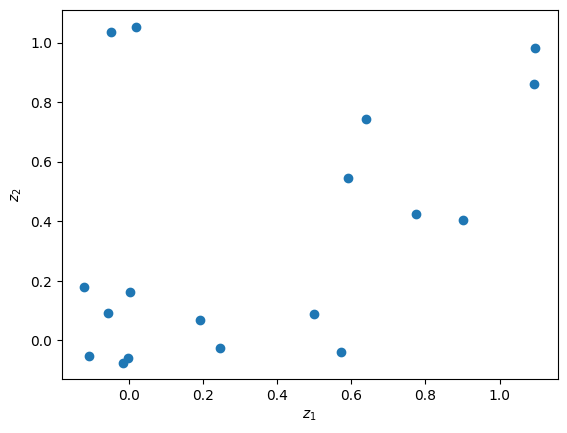

In [29]:
plt.scatter(z[:,0], z[:,1])
plt.xlabel("$z_1$")
plt.ylabel("$z_2$")
plt.show()

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from scipy.stats import chi2

def plot_bivariate_normal_contour(mean, cov, percentile=0.95, ax=None, **ellipse_kwargs):
    """
    Plots the contour of a bivariate normal distribution for a given percentile.

    Parameters:
        mean : array-like of shape (2,)
            Mean of the distribution.
        cov : array-like of shape (2,2)
            Covariance matrix.
        percentile : float
            Probability mass to enclose (default 0.95).
        ax : matplotlib Axes, optional
            Axes to draw on. If None, creates a new figure.
        ellipse_kwargs : additional kwargs for matplotlib.patches.Ellipse
            e.g., edgecolor, facecolor, linewidth, label
    """
    mean = np.asarray(mean)
    cov = np.asarray(cov)

    # Eigen decomposition
    eigvals, eigvecs = np.linalg.eigh(cov)
    order = eigvals.argsort()[::-1]  # descending
    eigvals, eigvecs = eigvals[order], eigvecs[:, order]

    # Rotation angle of ellipse
    angle = np.degrees(np.arctan2(eigvecs[1,0], eigvecs[0,0]))

    # Chi-square scaling for desired percentile
    s = chi2.ppf(percentile, df=2)

    # Width and height
    width, height = 2 * np.sqrt(eigvals * s)

    # Create plot if needed
    if ax is None:
        fig, ax = plt.subplots()

    # Draw ellipse
    ellipse = Ellipse(mean, width=width, height=height, angle=angle, **ellipse_kwargs)
    ax.add_patch(ellipse)
    
    return ax

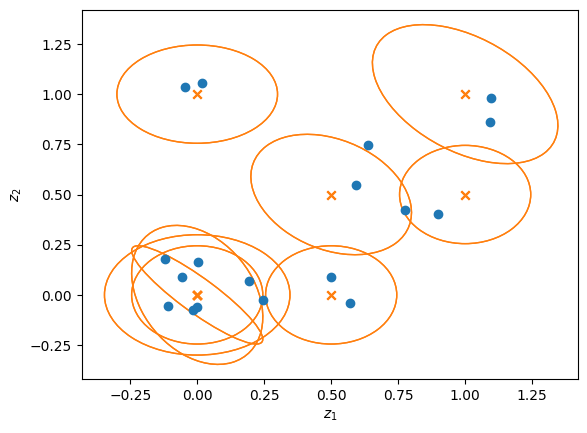

In [31]:
fig, ax = plt.subplots()
#ax.scatter(A.mean.T[:,0], A.mean.T[:,1])
ax.scatter(A.mean.T[:,0], A.mean.T[:,1], color = 'tab:orange', marker = 'x')

for i in range(len(A.mean.T)):
    plot_bivariate_normal_contour(mean = z_ref + A.mean[:,i], cov = c_ref + A.varcov[i], percentile=0.95, ax=ax, facecolor = 'none', edgecolor = "tab:orange")
    
ax.scatter(z[:,0], z[:,1], color = 'tab:blue')

plt.xlabel("$z_1$")
plt.ylabel("$z_2$")
plt.show()

## Fitness

### Neutral

In [32]:
hanoi.fit_neutral(z)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1.])

### Gaussian fitness function

In [33]:
hanoi.fit_gaus?

Signature: hanoi.fit_gaus(sigma, z_opt, z)
Docstring:
sigma: A scalar specifying SD around the peak
z_opt: (n,) array specifying the coordinate of the peak in the n dimensional phenotypic space
z:      (n, N) array representing n-dimensional phenotypes of N individuals.
Returns: (N,) array representing fitness of N individuals
File:      ~/Dropbox/work/projects/python/packages/hanoi/hanoi/fitness.py
Type:      function

For one trait

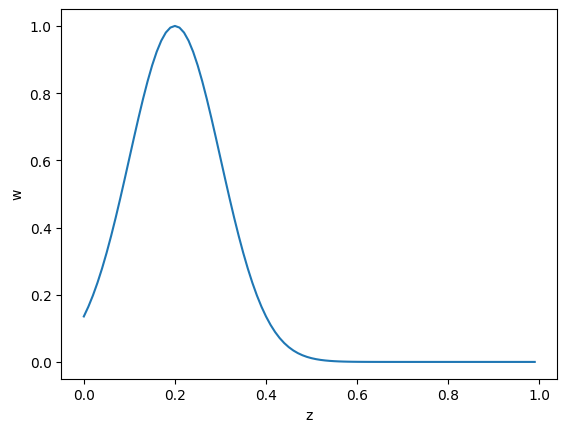

In [34]:
z_1D = np.arange(100, dtype = np.float64)/100
w1 = hanoi.fit_gaus(z_opt = np.array([0.2], dtype = np.float64), 
                    sigma = 0.1,
                    z = z_1D
                   )
plt.plot(z_1D, w1)
plt.xlabel("z")
plt.ylabel("w")
plt.show()

For 2 traits

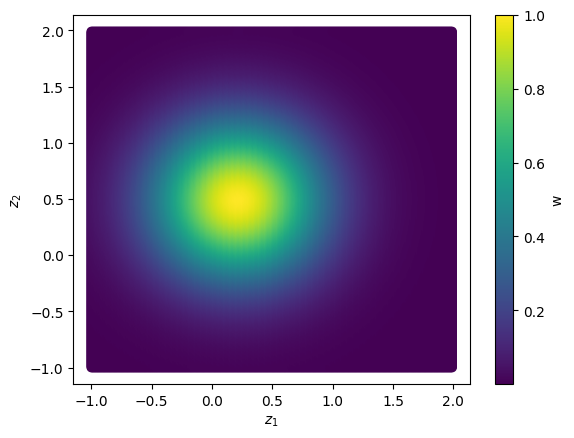

In [35]:
z2 = np.array([[x, y] for x in np.arange(-1,2,0.01) for y in np.arange(-1,2,0.01)], dtype = np.float64)
w2 = hanoi.fit_gaus(z_opt = np.array([0.25,0.5], dtype = np.float64),
               sigma = 0.5,
               z = z2
              )
plt.scatter(z2[:,0], z2[:,1], c=w2, cmap='viridis')
plt.colorbar(label='w')
plt.xlabel('$z_1$')
plt.ylabel('$z_2$')
plt.show()

We can apply this 2D Gaussian fitness function to the 2D traits

In [36]:
w=hanoi.fit_gaus(z_opt = np.array([0.25,0.5], dtype = np.float64),
               sigma = 0.5,
               z = z
              )

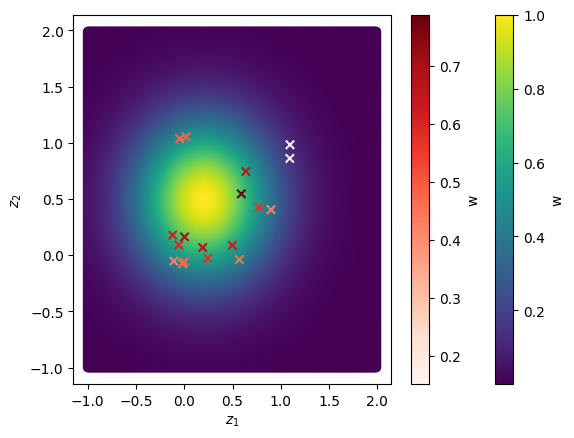

In [37]:
plt.scatter(z2[:,0], z2[:,1], c=w2, cmap='viridis')
plt.colorbar(label='w')
plt.scatter(z[:,0], z[:,1], c=w,  cmap='Reds', marker = "x")
plt.colorbar(label='w')
plt.xlabel('$z_1$')
plt.ylabel('$z_2$')
plt.show()

#